## Amazon Sales Optimization & Profitabiliy Intelligence 

##  Day 2 - Data Profiling 

## Objectives
- Load the Amazon Sales dataset
- Understand the dataset structure
- Analyze data types
- Check missing values
- Identify duplicates
- Analyze sales distribution
- Detect outliers
- Create initial observations

In [24]:
import os
print(os.getcwd())

C:\Users\SVS\Desktop\data-analysis-project\notebooks


## Import Libraries

In [33]:
import numpy as np
import matplotlib.pyplot as plt

In [37]:
## Load the dataset 
import pandas as pd 
df = pd.read_csv(r"C:\Users\SVS\Desktop\data-analysis-project\data\raw\Amazon Sale Report.csv")

C:\Users\SVS\AppData\Local\Temp\ipykernel_4112\3238385368.py:3: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"C:\Users\SVS\Desktop\data-analysis-project\data\raw\Amazon Sale Report.csv")


In [35]:
df.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [36]:
df.shape

(128975, 24)

In [30]:
df.columns

Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'B2B', 'fulfilled-by', 'Unnamed: 22'],
      dtype='object')

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  object 
 2   Date                128975 non-null  object 
 3   Status              128975 non-null  object 
 4   Fulfilment          128975 non-null  object 
 5   Sales Channel       128975 non-null  object 
 6   ship-service-level  128975 non-null  object 
 7   Style               128975 non-null  object 
 8   SKU                 128975 non-null  object 
 9   Category            128975 non-null  object 
 10  Size                128975 non-null  object 
 11  ASIN                128975 non-null  object 
 12  Courier Status      122103 non-null  object 
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  object 
 15  Amount              121180 non-nul

## Initial Data Modeling 

In [39]:
## checking Missing Values 
df[['Amount','ship-city','ship-state']].isnull().sum()

Amount        7795
ship-city       33
ship-state      33
dtype: int64

In [40]:
df.isnull().sum().sort_values(ascending=False)

fulfilled-by          89698
promotion-ids         49153
Unnamed: 22           49050
currency               7795
Amount                 7795
Courier Status         6872
ship-country             33
ship-postal-code         33
ship-state               33
ship-city                33
ship-service-level        0
Style                     0
Date                      0
B2B                       0
Status                    0
Fulfilment                0
Sales Channel             0
Qty                       0
Order ID                  0
ASIN                      0
Size                      0
Category                  0
SKU                       0
index                     0
dtype: int64

In [41]:
## Duplicate Values 
df.duplicated().sum()

np.int64(0)

## Data Distribution Analysis 

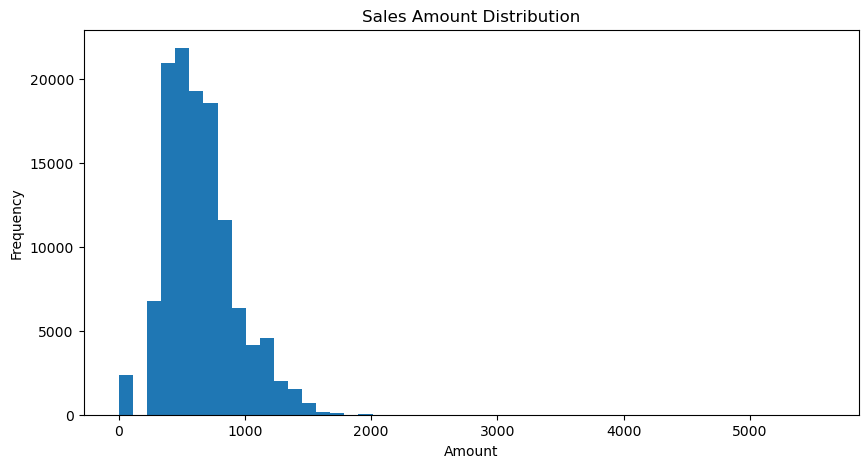

In [43]:
plt.figure(figsize=(10,5))

plt.hist(df['Amount'].dropna(), bins=50)

plt.title("Sales Amount Distribution")

plt.xlabel("Amount")

plt.ylabel("Frequency")

plt.show()

### observation 

- The distribution of the Amount column is positively  skewed.
- Most sales transactions are concentrated between approximately ₹300 and ₹1000.
- The frequency of transactions decreases as the sales amount increases.
- A small number of orders have very high sales amounts (greater than ₹1500), forming a long right tail.
- These high-value transactions may represent potential outliers and can influence summary statistics such as the mean and overall profitability calculations.
- Further investigation using a box plot and the IQR method is required to confirm the presence of outliers.

## Outlier Detection 

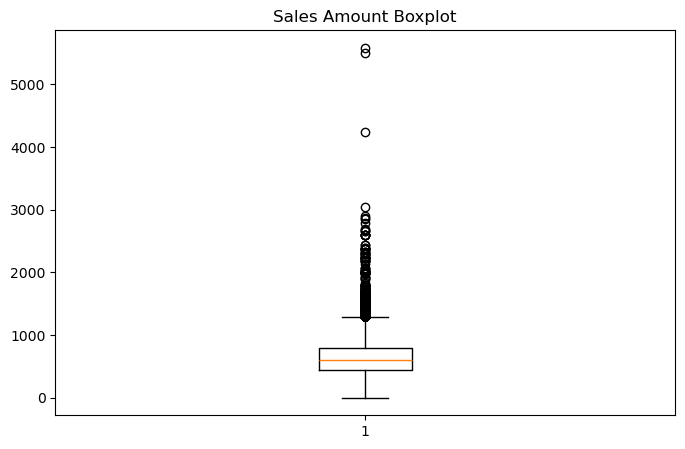

In [44]:
plt.figure(figsize=(8,5))

plt.boxplot(df['Amount'].dropna())

plt.title("Sales Amount Boxplot")

plt.show()

## Observation

- The boxplot indicates that the Amount  column contains a significant number of outliers.
- Most sales transactions are concentrated within the interquartile range (IQR), while several orders have sales amounts far above the upper whisker.
- The median sales amount lies approximately in the middle of the box, indicating that half of the orders fall below this value.
- Numerous high-value transactions (above approximately ₹1300) appear as outliers.
- The highest sales values reach nearly ₹5600, which are considerably higher than the majority of transactions.
- These extreme values may influence the mean, total revenue, and profitability calculations and should be carefully considered during further analysis.

In [45]:
Q1 = df['Amount'].quantile(0.25)

Q3 = df['Amount'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - (1.5 * IQR)

upper_limit = Q3 + (1.5 * IQR)

outliers = df[(df['Amount'] < lower_limit) | (df['Amount'] > upper_limit)]

print("Lower Limit :", lower_limit)

print("Upper Limit :", upper_limit)

print("Total Outliers :", len(outliers))

Lower Limit : -59.5
Upper Limit : 1296.5
Total Outliers : 3600


In [46]:
print("Minimum Sales :", df['Amount'].min())

print("Maximum Sales :", df['Amount'].max())

Minimum Sales : 0.0
Maximum Sales : 5584.0


## Data Dictionary 

In [47]:
data_dictionary = pd.DataFrame({
    "Column Name": df.columns,
    "Data Type": df.dtypes.astype(str)
})

data_dictionary

,Column Name,Data Type
index,index,int64
Order ID,Order ID,object
Date,Date,object
Status,Status,object
Fulfilment,Fulfilment,object
Sales Channel,Sales Channel,object
ship-service-level,ship-service-level,object
Style,Style,object
SKU,SKU,object
Category,Category,object


In [49]:
data_dictionary.to_excel("Data_Dictionary.xlsx", index=False)

print("Data Dictionary saved successfully!")

Data Dictionary saved successfully!
